<img src="https://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Finance (2nd ed.)

**Mastering Data-Driven Finance**

&copy; Dr. Yves J. Hilpisch | The Python Quants GmbH

<img src="https://hilpisch.com/images/py4fi_2nd_shadow.png" width="300px" align="left">

# Performance Python

It is a long-lived prejudice that Python per se is a relatively slow programming
language and not appropriate to implement computationally demanding tasks in
finance.

Beyond the fact that Python is an interpreted language, the reasoning is
usually along the following lines: Python is slow when it comes to loops; loops
are often required to implement financial algorithms; therefore Python is too
slow for financial algorithm implementation. Another line of reasoning is: other
(compiled) programming languages are fast at executing loops (such as C or
C++); loops are often required for financial algorithms; therefore these
(compiled) programming languages are well suited for finance and financial
algorithm implementation.

Admittedly, it is possible to write proper Python code that executes rather slowly
— perhaps too slowly for many application areas. This chapter is about
approaches to speed up typical tasks and algorithms often encountered in a
financial context. It shows that with a judicious use of data structures, choosing
the right implementation idioms and paradigms, as well as using the right
performance packages, Python is able to compete even with compiled
programming languages. This is due to, among other factors, getting compiled
itself.

To this end, this chapter introduces different approaches to speed up code:
</br> _Vectorization_
Making use of Python’s vectorization capabilities is one approach already
used extensively in previous chapters.
</br> _Dynamic compiling_
Using the Numba package allows one to dynamically compile pure Python
code using LLVM technology.
</br> _Static compiling_
Cython is not only a Python package but a hybrid language that combines
Python and C; it allows one, for instance, to use static type declarations and
to statically compile such adjusted code.
</br> _Multiprocessing_
The multiprocessing module of Python allows for easy and simple
parallelization of code execution.

This chapter addresses the following topics:
</br> _“Loops”_
This section addresses Python loops and how to speed them up.
</br> _“Algorithms”_
This section is concerned with standard mathematical algorithms that are
often used for performance benchmarks, such as Fibonacci number
generation.
</br> _“Binomial Trees”_
The binomial option pricing model is a widely used financial model that
allows for an interesting case study about a more involved financial
algorithm.
</br> _“Monte Carlo Simulation”_
Similarly, Monte Carlo simulation is widely used in financial practice for
pricing and risk management. It is computationally demanding and has long
been considered the domain of such languages as C or C++.
</br> _“Recursive pandas Algorithm”_
This section addresses the speedup of a recursive algorithm based on
financial time series data. In particular, it presents different
implementations for an algorithm calculating an exponentially weighted
moving average (EWMA).

In [1]:
import warnings
warnings.simplefilter('ignore')

## Loops

This section tackles the Python loop issue. The task is rather simple: a function
shall be written that draws a certain “large” number of random numbers and
returns the average of the values. The execution time is of interest, which can be
estimated by the magic functions %time and %timeit.

This sets the benchmark for the other approaches to follow.

---
### Python

In [2]:
import random

In [3]:
def average_py(n):
    s = 0  
    for i in range(n):
        s += random.random()  
    return s / n  

In [4]:
n = 10000000  

In [5]:
%time average_py(n)  

CPU times: user 993 ms, sys: 12.2 ms, total: 1.01 s
Wall time: 1.02 s


0.5000588361101697

In [6]:
%timeit average_py(n)  

968 ms ± 25.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
%time sum([random.random() for _ in range(n)]) / n  

CPU times: user 1.06 s, sys: 169 ms, total: 1.23 s
Wall time: 1.24 s


0.49985370562187376

---
### NumPy

The strength of NumPy lies in its vectorization capabilities. Formally, loops
vanish on the Python level; the looping takes place one level deeper based on
optimized and compiled routines provided by NumPy.

The function
average_np() makes use of this approach:

In [8]:
import numpy as np

In [9]:
def average_np(n):
    s = np.random.random(n)
    return s.mean()

In [10]:
%time average_np(n)

CPU times: user 76.5 ms, sys: 7.99 ms, total: 84.5 ms
Wall time: 84.5 ms


np.float64(0.49992789210091615)

In [11]:
%timeit average_np(n)

72.9 ms ± 2.15 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [12]:
s = np.random.random(n)
s.nbytes

80000000

The speedup is considerable, reaching almost a factor of 10 or an order of
magnitude. However, the price that must be paid is significantly higher memory
usage. This is due to the fact that NumPy attains speed by preallocating data that
can be processed in the compiled layer. As a consquence, there is no way, given
this approach, to work with “streamed” data. This increased memory usage
might even be prohibitively large depending on the algorithm or problem at
hand.

#### VECTORIZATION AND MEMORY
It is tempting to write vectorized code with NumPy whenever possible due to the concise syntax
and speed improvements typically observed. However, these benefits often come at the price
of a much higher memory footprint.

---
### Numba

Numba is a package that allows the dynamic compiling of pure Python code by
the use of LLVM.

The application in a simple case, like the one at hand, is
surprisingly straightforward and the dynamically compiled function
average_nb() can be called directly from Python:

In [13]:
import numba

In [14]:
# average_py was our custom function
average_nb = numba.jit(average_py, nopython=True)  

In [15]:
%time average_nb(n)  

CPU times: user 1.15 s, sys: 81.7 ms, total: 1.23 s
Wall time: 1.07 s


0.49982556313760085

In [16]:
%time average_nb(n)  

CPU times: user 213 ms, sys: 944 μs, total: 214 ms
Wall time: 215 ms


0.5000203957263016

In [17]:
%timeit average_nb(n)  

225 ms ± 9.48 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


The combination of pure Python with Numba beats the NumPy version and
preserves the memory efficiency of the original loop-based implementation. It is
also obvious that the application of Numba in such simple cases comes with
hardly any programming overhead.

---
### Cython

Cython allows one to statically compile Python code. However, the application is
not as simple as with Numba since the code generally needs to be changed to see
significant speed improvements.

To begin with, consider the Cython function
`average_cy1()`, which introduces static type declarations for the used variables:

In [18]:
%load_ext Cython

In [19]:
%%cython -a
import random  
def average_cy1(int n):  
    cdef int i  
    cdef float s = 0  
    for i in range(n):
        s += random.random()
    return s / n

In [20]:
%time average_cy1(n)

CPU times: user 598 ms, sys: 953 μs, total: 599 ms
Wall time: 599 ms


0.5001034736633301

In [21]:
%timeit average_cy1(n)

574 ms ± 38.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Some speedup is observed, but not even close to that achieved by, for example,
the NumPy version.

A bit more Cython optimization is necessary to beat even the
Numba version:

In [22]:
%%cython
from libc.stdlib cimport rand  
cdef extern from 'limits.h':  
    int INT_MAX  
cdef int i
cdef float rn
for i in range(5):
    rn = rand() / INT_MAX  
    print(rn)

0.47739705443382263
0.6288709044456482
0.36478447914123535
0.5134009122848511
0.9522297382354736


In [23]:
%%capture
%%cython -a
from libc.stdlib cimport rand  
cdef extern from 'limits.h':  
    int INT_MAX  
def average_cy2(int n):
    cdef int i
    cdef float s = 0
    for i in range(n):
        s += rand() / INT_MAX  
    return s / n

In [24]:
%time average_cy2(n)

CPU times: user 152 ms, sys: 0 ns, total: 152 ms
Wall time: 152 ms


0.5000253915786743

In [25]:
%timeit average_cy2(n)

153 ms ± 2.77 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


This further optimized Cython version, average_cy2(), is now a bit faster than
the Numba version. However, the effort has also been a bit larger.

Compared to
the NumPy version, Cython also preserves the memory efficiency of the original
loop-based implementation.

#### CYTHON = PYTHON + C
Cython allows developers to tweak code for performance as much as possible or as little as
sensible — starting with a pure Python version, for instance, and adding more and more
elements from C to the code. The compilation step itself can also be parameterized to further
optimize the compiled version.

---
## Prime Numbers

Prime numbers play an important role not only in theoretical mathematics but
also in many applied computer science disciplines, such as encryption. A prime
number is a positive natural number greater than 1 that is only divisible without
remainder by 1 and itself. There are no other factors.

While it is difficult to find
larger prime numbers due to their rarity, it is easy to prove that a number is not
prime. The only thing that is needed is a factor other than 1 that divides the
number without a remainder.

### Pure Python
There are a number of algorithmic implementations available to test if numbers
are prime. The following is a Python version that is not yet optimal from an
algorithmic point of view but is already quite efficient. The execution time for
the larger prime p2, however, is long:

In [26]:
def is_prime(I):
    if I % 2 == 0: return False  
    for i in range(3, int(I ** 0.5) + 1, 2):  
        if I % i == 0: return False  
    return True  

In [27]:
n = int(1e8 + 3)  
n

100000003

In [28]:
%time is_prime(n)

CPU times: user 68 μs, sys: 2 μs, total: 70 μs
Wall time: 188 μs


False

In [29]:
p1 = int(1e8 + 7)  
p1

100000007

In [30]:
%time is_prime(p1)

CPU times: user 676 μs, sys: 0 ns, total: 676 μs
Wall time: 706 μs


True

In [31]:
p2 = 100109100129162907  

In [32]:
p2.bit_length()  

57

In [33]:
%time is_prime(p2)

CPU times: user 14.6 s, sys: 6.91 ms, total: 14.6 s
Wall time: 14.7 s


True

---
### Numba

The loop structure of the algorithm in the function is_prime() lends itself well
to being dynamically compiled with Numba. The overhead again is minimal but
the speedup considerable:

In [34]:
is_prime_nb = numba.jit(is_prime, nopython=True)

In [35]:
%time is_prime_nb(n)  

CPU times: user 97.3 ms, sys: 2.96 ms, total: 100 ms
Wall time: 109 ms


False

In [36]:
%time is_prime_nb(n)  

CPU times: user 6 μs, sys: 0 ns, total: 6 μs
Wall time: 9.78 μs


False

In [37]:
%time is_prime_nb(p1)

CPU times: user 22 μs, sys: 1 μs, total: 23 μs
Wall time: 25.7 μs


True

In [38]:
%time is_prime_nb(p2)  

CPU times: user 1.36 s, sys: 7.92 ms, total: 1.37 s
Wall time: 1.37 s


True

---
### Cython

The application of Cython is straightforward as well. A plain Cython version
without type declarations already speeds up the code significantly:

However, real improvements only materialize with the static type declarations.
The Cython version then even is slightly faster than the Numba one:

In [39]:
%%capture
%%cython
def is_prime_cy1(I):
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        if I % i == 0: return False
    return True

In [40]:
%timeit is_prime(p1)

293 μs ± 11.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [41]:
%timeit is_prime_cy1(p1)

157 μs ± 1.39 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [42]:
%%capture
%%cython
def is_prime_cy2(long I):  
    cdef long i  
    if I % 2 == 0: return False
    for i in range(3, int(I ** 0.5) + 1, 2):
        if I % i == 0: return False
    return True

In [43]:
%timeit is_prime_cy2(p1)

41.5 μs ± 1e+03 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [44]:
%time is_prime_nb(p2)

CPU times: user 1.39 s, sys: 1.94 ms, total: 1.39 s
Wall time: 1.39 s


True

In [45]:
%time is_prime_cy2(p2)

CPU times: user 1.29 s, sys: 1.99 ms, total: 1.3 s
Wall time: 1.3 s


True

### Multiprocessing

So far, all the optimization efforts have focused on the sequential code
execution. In particular with prime numbers, there might be a need to check
multiple numbers at the same time.

To this end, the multiprocessing module
can help speed up the code execution further. It allows one to spawn multiple
Python processes that run in parallel. The application is straightforward in the
simple case at hand. First, an mp.

Pool object is set up with multiple processes.
Second, the function to be executed is mapped to the prime numbers to be
checked:

<b style="color: red;">This currently does not work on Macs with Apple Silicon.</b>

See also [R4P Gemini](https://gemini.google.com/app/b1efd8e28c627639?hl=it)

<b style="color: red;">Also on stampede, it eats up everything.</b>

In [46]:
# import multiprocessing as mp

In [47]:
# pool = mp.Pool(processes=4)

In [48]:
# %time pool.map(is_prime, 10 * [p1])

In [49]:
# %time pool.map(is_prime_nb, 10 * [p2])

In [50]:
# %time pool.map(is_prime_cy2, 10 * [p2])

The observed speedup is significant. The Python function is_prime() takes
more than 20 seconds for the larger prime number p2. Both the is_prime_nb()
and the is_prime_cy2() functions take less than 10 seconds for 10 times the
prime number p2 when executed in parallel with four processes

#### PARALLEL PROCESSING
Parallel processing should be considered whenever different problems of the same type need to
be solved. The effect can be huge when powerful hardware is available with many cores and
sufficient working memory. multiprocessing is one easy-to-use module from the standard
library.

---
## Fibonacci Numbers

Fibonacci numbers and sequences can be derived based on a simple algorithm.
Start with two ones: 1, 1. From the third number, the next Fibonacci number is
derived as the sum of the two preceding ones: 1, 1, 2, 3, 5, 8, 13, 21, …. This
section analyzes two different implementations, a recursive one and an iterative
one.

### Recursive algorithm
Similar to regular Python loops, it is known that regular recursive function
implementations are relatively slow with Python. Such functions call themselves
potentially a large number of times to come up with the final result. The function
fib_rec_py1() presents such an implementation. In this case, Numba does not
help at all with speeding up the execution. However, Cython shows significant
speedups based on static type declarations only:

In [51]:
from numba import njit

In [52]:
def fib_rec_py1(n):
    if n < 2:
        return n
    else:
        return fib_rec_py1(n - 1) + fib_rec_py1(n - 2)

In [53]:
%time fib_rec_py1(35)

CPU times: user 2.59 s, sys: 1.87 ms, total: 2.6 s
Wall time: 2.65 s


9227465

In [54]:
@njit
def fib_rec_nb(n):
    if n < 2:
        return n
    else:
        return fib_rec_nb(n - 1) + fib_rec_nb(n - 2)

In [55]:
%time fib_rec_nb(35)

CPU times: user 136 ms, sys: 997 μs, total: 137 ms
Wall time: 144 ms


9227465

In [56]:
%time fib_rec_nb(35)

CPU times: user 63.4 ms, sys: 0 ns, total: 63.4 ms
Wall time: 64 ms


9227465

In [57]:
%%cython
def fib_rec_cy(int n):
    if n < 2:
        return n
    else:
        return fib_rec_cy(n - 1) + fib_rec_cy(n - 2)

In [58]:
%time fib_rec_cy(35)

CPU times: user 677 ms, sys: 1.95 ms, total: 679 ms
Wall time: 683 ms


9227465

The major problem with the recursive algorithm is that intermediate results are
not cached but rather recalculated.

To avoid this particular problem, a decorator
can be used that takes care of the caching of intermediate results.

This speeds up
the execution by multiple orders of magnitude:

In [59]:
from functools import lru_cache as cache

In [60]:
@cache(maxsize=None)  
def fib_rec_py2(n):
    if n < 2:
        return n
    else:
        return fib_rec_py2(n - 1) + fib_rec_py2(n - 2)

In [61]:
%time fib_rec_py2(35)  

CPU times: user 41 μs, sys: 1e+03 ns, total: 42 μs
Wall time: 46.3 μs


9227465

In [62]:
%time fib_rec_py2(80)  

CPU times: user 24 μs, sys: 1e+03 ns, total: 25 μs
Wall time: 27.9 μs


23416728348467685

---
### Iterative Algorithm

Although the algorithm to calculate the nth Fibonacci number can be
implemented recursively, it doesn’t have to be.

The following presents an
iterative implementation which is even in pure Python faster than the cached
variant of the recursive implementation.

This is also the terrain where Numba
leads to further improvements.

However, the Cython version comes out as the
winner:

In [63]:
def fib_it_py(n):
    x, y = 0, 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

In [64]:
%time fib_it_py(80)

CPU times: user 16 μs, sys: 0 ns, total: 16 μs
Wall time: 21.2 μs


23416728348467685

In [65]:
fib_it_nb = numba.jit(fib_it_py)

In [66]:
%time fib_it_nb(80)

CPU times: user 74.2 ms, sys: 987 μs, total: 75.1 ms
Wall time: 75 ms


23416728348467685

In [67]:
%time fib_it_nb(80)

CPU times: user 10 μs, sys: 0 ns, total: 10 μs
Wall time: 14.8 μs


23416728348467685

In [68]:
%%cython
def fib_it_cy1(int n):
    cdef long i
    cdef long x = 0, y = 1
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

In [69]:
%time fib_it_cy1(80)

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 8.58 μs


23416728348467685

Now that everything is so fast, one might wonder why we’re just calculating the
80th Fibonacci number and not the 150th, for instance.

The problem is with the
available data types.

While Python can basically handle arbitrarily large numbers
(see “Basic Data Types”), this is not true in general for the compiled languages.

With Cython one can, however, rely on a special data type to allow for numbers
larger than the double float object with 64 bits allows for:

In [70]:
%%time
fn = fib_rec_py2(150)  
print(fn)  

9969216677189303386214405760200
CPU times: user 285 μs, sys: 4 μs, total: 289 μs
Wall time: 231 μs


In [71]:
fn.bit_length()  

103

In [72]:
%%time 
fn = fib_it_nb(150)  
print(fn)  

6792540214324356296
CPU times: user 0 ns, sys: 67 μs, total: 67 μs
Wall time: 84.4 μs


In [73]:
fn.bit_length()  

63

In [74]:
%%time
fn = fib_it_cy1(150)  
print(fn)  

6792540214324356296
CPU times: user 67 μs, sys: 1 μs, total: 68 μs
Wall time: 72.2 μs


In [75]:
fn.bit_length()  

63

In [76]:
%%cython
cdef extern from *:
    ctypedef int int128 '__int128_t'  
def fib_it_cy2(int n):
    cdef int128 i  
    cdef int128 x = 0, y = 1  
    for i in range(1, n + 1):
        x, y = y, x + y
    return x

In [77]:
%%time
fn = fib_it_cy2(150)  
print(fn)  

9969216677189303386214405760200
CPU times: user 56 μs, sys: 1e+03 ns, total: 57 μs
Wall time: 60.3 μs


In [78]:
fn.bit_length()  

103

---
## The Number Pi

The final algorithm analyzed in this section is a Monte Carlo simulation–based
algorithm to derive digits for the number pi. The basic idea relies on the fact
that the area A of a circle is given by $$A = \pi * r^2$$

For a unit
circle with radius r = 1, it holds that π = A. The idea of the algorithm is to
simulate random points with coordinate values (x, y), with x, y ∈ [–1, 1].

The
area of an origin-centered square with side length of 2 is exactly 4. The area of
the origin-centered unit circle is a fraction of the area of such a square.

This
fraction can be estimated by Monte Carlo simulation: count all the points in the
square, then count all the points in the circle, and divide the number of points in
the circle by the number of points in the square.

The following example
demonstrates.
The code example is taken from [StackExchange](https://codereview.stackexchange.com/questions/69370/monte-carlo-pi-calculation).

In [79]:
import random
import numpy as np
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%config InlineBackend.figure_format = 'svg'

In [80]:
rn = [(random.random() * 2 - 1, random.random() * 2 - 1)
      for _ in range(500)]

In [81]:
rn = np.array(rn)
rn[:5]

array([[-0.38533467,  0.62338749],
       [-0.07656695, -0.53416081],
       [ 0.88585104, -0.43772629],
       [-0.82735505, -0.16482988],
       [ 0.64972909, -0.35839415]])

(-1.1, 1.1)

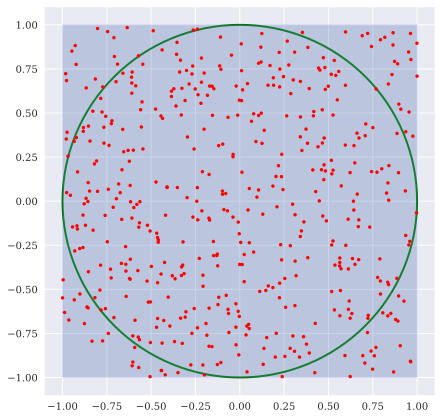

In [82]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1)
circ = plt.Circle((0, 0), radius=1, edgecolor='g', lw=2.0,
                  facecolor='None')
box = plt.Rectangle((-1, -1), 2, 2, edgecolor='b', alpha=0.3)
ax.add_patch(circ)
ax.add_patch(box)
plt.plot(rn[:, 0], rn[:, 1], 'r.')
plt.ylim(-1.1, 1.1)
plt.xlim(-1.1, 1.1)

A NumPy implementation of this algorithm is rather concise but also memory-
intensive. Total execution time given the parameterization is about one second:

In [83]:
n = int(1e7)

In [84]:
%time rn = np.random.random((n, 2)) * 2 - 1

CPU times: user 169 ms, sys: 9.96 ms, total: 179 ms
Wall time: 179 ms


In [85]:
rn.nbytes

160000000

In [86]:
%time distance = np.sqrt((rn ** 2).sum(axis=1))  
distance[:8].round(3)

CPU times: user 204 ms, sys: 22.8 ms, total: 227 ms
Wall time: 230 ms


array([1.243, 0.581, 0.468, 0.862, 0.818, 0.904, 0.552, 0.783])

In [87]:
%time frac = (distance <= 1.0).sum() / len(distance)  

CPU times: user 14.2 ms, sys: 2.9 ms, total: 17.1 ms
Wall time: 15.8 ms


In [88]:
pi_mcs = frac * 4  
pi_mcs  

np.float64(3.1412632)

mcs_pi_py() is a Python function using a for loop and implementing the Monte
Carlo simulation in a memory-efficient manner.

Note that the random numbers
are not scaled in this case.

The execution time is longer than with the NumPy
version, but the Numba version is faster than NumPy in this case:

In [89]:
def mcs_pi_py(n):
    circle = 0
    for _ in range(n):
        x, y = random.random(), random.random()
        if (x ** 2 + y ** 2) ** 0.5 <= 1:
            circle += 1
    return (4 * circle) / n

In [90]:
%time mcs_pi_py(n)

CPU times: user 4.07 s, sys: 997 μs, total: 4.07 s
Wall time: 4.08 s


3.1414212

In [91]:
mcs_pi_nb = numba.jit(mcs_pi_py)

In [92]:
%time mcs_pi_nb(n)

CPU times: user 669 ms, sys: 998 μs, total: 670 ms
Wall time: 674 ms


3.1418028

In [93]:
%time mcs_pi_nb(n)

CPU times: user 515 ms, sys: 2.97 ms, total: 518 ms
Wall time: 522 ms


3.1417592

A plain Cython version with static type declarations only does not perform that
much faster than the Python version.

However, relying again on the random
number generation capabilities of C further speeds up the calculation
considerably:

In [94]:
%%capture
%%cython -a
import random
def mcs_pi_cy1(int n):
    cdef int i, circle = 0
    cdef float x, y, z
    for i in range(n):
        x, y = random.random(), random.random()
        z = (x ** 2 + y ** 2) ** 0.5
        if z <= 1:
            circle += 1
    return (4 * circle) / n

In [95]:
%time mcs_pi_cy1(n)

CPU times: user 1.06 s, sys: 2.94 ms, total: 1.06 s
Wall time: 1.07 s


3.141138

In [96]:
%%capture
%%cython -a
from libc.stdlib cimport rand
cdef extern from 'limits.h':
    int INT_MAX
def mcs_pi_cy2(int n):
    cdef int i, circle = 0
    cdef float x, y, z
    for i in range(n):
        x, y = rand() / INT_MAX, rand() / INT_MAX
        z = (x ** 2 + y ** 2) ** 0.5
        if z <= 1:
            circle += 1
    return (4 * circle) / n

In [97]:
%time mcs_pi_cy2(n)

CPU times: user 447 ms, sys: 1.97 ms, total: 449 ms
Wall time: 448 ms


3.1411124

#### ALGORITHM TYPES
The algorithms analyzed in this section might not be directly related to financial algorithms.
However, the advantage is that they are simple and easy to understand. In addition, typical
algorithmic problems encountered in a financial context can be discussed within this simplified
context.

---
## Binomial Trees

A popular numerical method to value options is the binomial option pricing
model pioneered by Cox, Ross, and Rubinstein (1979). This method relies on
representing the possible future evolution of an asset by a (recombining) tree. In
this model, as in the Black-Scholes-Merton (1973) setup, there is a risky asset,
an index or stock, and a riskless asset, a bond.

The relevant time interval from
today until the maturity of the option is divided in general into equidistant
subintervals of length $\Delta t$.

Given an index level at time s of $S_s$, the index level at $t = s + \Delta t$
 is given by $S_t = S_s * m$, where $m$ is chosen randomly from $\{u, d\}$.

With $$0 < d < e^{r\Delta t} < u$$
As well as $$u = \frac{1}{d}$$

$r$ is the constant, riskless short rate.

---
### Python

Contrary to what happens in typical tree plots, an upward movement is
represented in the ndarray object as a sideways movement, which decreases the
ndarray size considerably:

In [98]:
import math

In [99]:
# where are we starting?
S0 = 36.
# How long until the contract expires?
T = 1.0
# What could I earn in a safe bank account?
r = 0.06
# How wild/risky is this stock usually?
sigma = 0.2

In [100]:
def simulate_tree(M):
    dt = T / M
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    S = np.zeros((M + 1, M + 1))
    S[0, 0] = S0
    z = 1
    for t in range(1, M + 1):
        for i in range(z):
            S[i, t] = S[i, t-1] * u
            S[i+1, t] = S[i, t-1] * d
        z += 1
    return S

In [101]:
np.set_printoptions(formatter={'float':
                               lambda x: '%6.2f' % x})

In [102]:
simulate_tree(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]])

In [103]:
%time simulate_tree(500)

CPU times: user 91.4 ms, sys: 985 μs, total: 92.4 ms
Wall time: 96.9 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

---
### NumPy

In the NumPy case, the code is a bit more compact. However, more importantly,
NumPy vectorization achieves a speedup of an order of magnitude while not using
more memory:

In [104]:
M = 4

In [105]:
up = np.arange(M + 1)
up = np.resize(up, (M + 1, M + 1))
up

array([[0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4]])

In [106]:
down = up.T * 2
down

array([[0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [4, 4, 4, 4, 4],
       [6, 6, 6, 6, 6],
       [8, 8, 8, 8, 8]])

In [107]:
up - down

array([[ 0,  1,  2,  3,  4],
       [-2, -1,  0,  1,  2],
       [-4, -3, -2, -1,  0],
       [-6, -5, -4, -3, -2],
       [-8, -7, -6, -5, -4]])

In [108]:
dt = T / M

In [109]:
S0 * np.exp(sigma * math.sqrt(dt) * (up - down))

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [ 29.47,  32.57,  36.00,  39.79,  43.97],
       [ 24.13,  26.67,  29.47,  32.57,  36.00],
       [ 19.76,  21.84,  24.13,  26.67,  29.47],
       [ 16.18,  17.88,  19.76,  21.84,  24.13]])

In [110]:
def simulate_tree_np(M):
    dt = T / M
    up = np.arange(M + 1)
    up = np.resize(up, (M + 1, M + 1))
    down = up.transpose() * 2
    S = S0 * np.exp(sigma * math.sqrt(dt) * (up - down))
    return S

In [111]:
simulate_tree_np(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [ 29.47,  32.57,  36.00,  39.79,  43.97],
       [ 24.13,  26.67,  29.47,  32.57,  36.00],
       [ 19.76,  21.84,  24.13,  26.67,  29.47],
       [ 16.18,  17.88,  19.76,  21.84,  24.13]])

In [112]:
%time simulate_tree_np(500)

CPU times: user 8.25 ms, sys: 1.99 ms, total: 10.2 ms
Wall time: 9.52 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [ 35.36,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [ 34.73,  35.05,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.41,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.40,   0.41,   0.41]],
      shape=(501, 501))

---
### Numba

This financial algorithm should be well suited to optimization through Numba
dynamic compilation. And indeed, another speedup compared to the NumPy
version of an order of magnitude is observed. This makes the Numba version
orders of magnitude faster than the Python (or rather hybrid) version:

In [113]:
simulate_tree_nb = numba.jit(simulate_tree)

In [114]:
simulate_tree_nb(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]])

In [115]:
%time simulate_tree_nb(500)

CPU times: user 271 μs, sys: 0 ns, total: 271 μs
Wall time: 274 μs


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

In [116]:
%timeit simulate_tree_nb(500)

215 μs ± 9.67 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


---
### Cython

As before, Cython requires more adjustments to the code to see significant
improvements.

The following version uses mainly static type declarations and
certain imports that improve the performance compared to the regular Python
imports and functions.

The Cython version shaves off another 30% of the execution time compared to
the Numba version.

In [117]:
%%cython -a
import numpy as np
cimport cython
from libc.math cimport exp, sqrt
cdef float S0 = 36.
cdef float T = 1.0
cdef float r = 0.06
cdef float sigma = 0.2
def simulate_tree_cy(int M):
    cdef int z, t, i
    cdef float dt, u, d
    cdef float[:, :] S = np.zeros((M + 1, M + 1),
                                  dtype=np.float32)  
    dt = T / M
    u = exp(sigma * sqrt(dt))
    d = 1 / u
    S[0, 0] = S0
    z = 1
    for t in range(1, M + 1):
        for i in range(z):
            S[i, t] = S[i, t-1] * u
            S[i+1, t] = S[i, t-1] * d
        z += 1
    return np.array(S)

In [118]:
simulate_tree_cy(4)

array([[ 36.00,  39.79,  43.97,  48.59,  53.71],
       [  0.00,  32.57,  36.00,  39.79,  43.97],
       [  0.00,   0.00,  29.47,  32.57,  36.00],
       [  0.00,   0.00,   0.00,  26.67,  29.47],
       [  0.00,   0.00,   0.00,   0.00,  24.13]], dtype=float32)

In [119]:
%time simulate_tree_cy(500)

CPU times: user 1.57 ms, sys: 9 μs, total: 1.58 ms
Wall time: 1.33 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.77, 3123.59, 3151.65],
       [  0.00,  35.68,  36.00, ..., 3040.89, 3068.21, 3095.77],
       [  0.00,   0.00,  35.36, ..., 2986.97, 3013.81, 3040.89],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501), dtype=float32)

In [120]:
%timeit S = simulate_tree_cy(500)

280 μs ± 14.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


---
## Monte Carlo Simulation

Monte Carlo simulation is an indispensible numerical tool in computational
finance. It has been in use since long before the advent of modern computers.
Banks and other financial institutions use it, among others, for pricing and risk
management purposes.

As a numerical method it is perhaps the most flexible and
powerful one in finance. However, it often also is the most computationally
demanding one. 

hat is why Python was long dismissed as a proper
programming language to implement algorithms based on Monte Carlo
simulation — at least for real-world application scenarios.

This section analyzes the Monte Carlo simulation of the geometric Brownian
motion, a simple yet still widely used stochastic process to model the evolution
of stock prices or index levels. Among others, the Black-Scholes-Merton (1973)
theory of option pricing draws on this process.

In their setup the underlying of
the option to be valued follows the stochastic differential equation (SDE), as
seen in Equation 10-1.
$$d S_t = r S_t d_t + \sigma S_t d Z_t$$

* $S_t$ is the value of the underlying at time $t$
* $r$ is the constant, riskless short rate
* $\sigma$ is the constant instantaneous volatility
* $Z_t$ is a Brownian motion

This SDE can be discretized over equidistant time intervals and simulated
according to Equation 10-2:
$$S_t = S_{t-\delta_t} \exp ((r - \frac{\sigma^2}{2}) \Delta_t + \sigma \sqrt{\Delta_t z})$$

 which represents an Euler scheme. In this case, $z$ is
a standard normally distributed random number.

For $M$ time intervals, the length of the time interval is given as
$$\Delta t  = \frac{T}{M}$$

Where $T$ is the time horizon for the simulation (for example, the maturity date of an option to be valued).

[R4P Gemini](https://gemini.google.com/app/d18cd77cacd8d607?hl=it) helped me a lot.

---
### Python
First, a Python — or rather a hybrid — version, mcs_simulation_py(), that
implements the Monte Carlo simulation according to Equation 10-2.

It is hybrid
since it implements Python loops on ndarray objects. As seen previously, this
might make for a good basis to dynamically compile the code with Numba.

As
before, the execution time sets the benchmark. Based on the simulation, a
European put option is valued:

In [173]:
# The number of time intervals for discretization
M = 100
# The number of paths to be simulated
I = 50000

In [174]:
def mcs_simulation_py(p):
    M, I = p
    dt = T / M
    # Rows: Time steps (from Today to End Date)
    # Columns: Different simulated paths
    S = np.zeros((M + 1, I))
    # S0 was described inside Binomial Tree section and its equal to 36.
    S[0] = S0
    rn = np.random.standard_normal(S.shape)
    for t in range(1, M + 1):
        for i in range(I):
            S[t, i] = S[t-1, i] * math.exp((r - sigma ** 2 / 2) * dt +
                                         sigma * math.sqrt(dt) * rn[t, i])
    return S

In [172]:
%time S = mcs_simulation_py((M, I))

CPU times: user 4.36 s, sys: 9.76 ms, total: 4.37 s
Wall time: 4.39 s


In [124]:
# The mean end-of-period value based on the simulation
S[-1].mean()

np.float64(38.27416585659237)

In [125]:
# The theoretically expected end-of-period value
S0 * math.exp(r * T)

38.22611567563295

After running the simulation, the code uses the results to price a European Put Option.

**A Put Option gives you the right to sell a stock at a specific Strike Price**.

You make money if the stock price drops below K.

In [126]:
# The strike price of the European put option
K = 40.

In [178]:
# If the final price is above K, the option is worthless
payoff = np.maximum(K - S[-1], 0)

# there are I paths...
mean_payoff = payoff.mean()

# It discounts that value back to today's money
# "Discounting" is simply the mathematical process of removing the interest to find out what a future pile of cash is worth right now.
# This weird-looking term is the mathematical "time machine" that brings that future money back to the present.
today_discount = math.exp(-r * T)

# The Monte Carlo estimator for the option
C0 = today_discount * mean_payoff

print(f'C0 = {today_discount} * {mean_payoff} = {C0}')

C0 = 0.9417645335842487 * 4.072125476074351 = 3.834983349671698


* $K$ (Strike Price): This is part of the product definition, not the cost. Think of it like the specifications of a car (e.g., "This contract lets me sell at $40").

* $C_0$ (The Result): This is the Fair Value (or Premium). This is what the simulation calculates the product is worth right now.

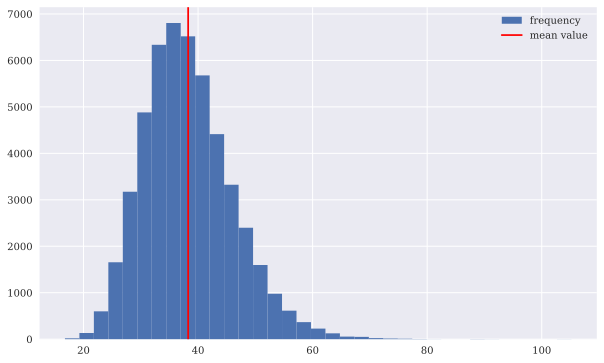

In [129]:
plt.figure(figsize=(10, 6))
plt.hist(S[-1], bins=35, label='frequency')
plt.axvline(S[-1].mean(), color='r', label='mean value')
plt.legend(loc=0)

### NumPy

The NumPy version, `mcs_simulation_np()`, is not too different. It still has one
Python loop, namely over the time intervals. The other dimension is handled by
vectorized code over all paths. It is about 20 times faster than the first version:

In [130]:
def mcs_simulation_np(p):
    M, I = p
    dt = T / M
    S = np.zeros((M + 1, I))
    S[0] = S0
    rn = np.random.standard_normal(S.shape)
    for t in range(1, M + 1):  
        S[t] = S[t-1] * np.exp((r - sigma ** 2 / 2) * dt +
                               sigma * math.sqrt(dt) * rn[t]) 
    return S      

In [131]:
%time S = mcs_simulation_np((M, I))

CPU times: user 158 ms, sys: 8.94 ms, total: 167 ms
Wall time: 167 ms


In [132]:
S[-1].mean()

np.float64(38.270713308353244)

In [133]:
%timeit S = mcs_simulation_np((M, I))

160 ms ± 3.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Numba

It should not come as a surprise anymore that Numba is applied to such an
algorithm type easily, and with significant performance improvements. The
Numba version, `mcs_simulation_nb()`, is slightly faster than the NumPy version:

In [134]:
mcs_simulation_nb = numba.jit(mcs_simulation_py)

In [135]:
%time S = mcs_simulation_nb((M, I))  

CPU times: user 1.04 s, sys: 39.8 ms, total: 1.08 s
Wall time: 1.12 s


In [136]:
%time S = mcs_simulation_nb((M, I))  

CPU times: user 370 ms, sys: 37.9 ms, total: 408 ms
Wall time: 408 ms


In [137]:
S[-1].mean()

np.float64(38.18619209572174)

In [138]:
C0 = math.exp(-r * T) * np.maximum(K - S[-1], 0).mean()

In [139]:
C0

np.float64(3.870071679370441)

In [140]:
%timeit S = mcs_simulation_nb((M, I))  

404 ms ± 8.24 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Cython &mdash; Sequential

With Cython, again not surprisingly, the effort required to speed up the code is
higher. However, the speedup itself is not greater. The Cython version,
`mcs_simulation_cy()`, seems to be even a bit slower compared to the NumPy and
Numba versions. Among other factors, some time is needed to transform the
simulation results to an ndarray object:

In [141]:
%%capture
%%cython
import numpy as np
cimport numpy as np
cimport cython
from libc.math cimport exp, sqrt
cdef float S0 = 36.
cdef float T = 1.0
cdef float r = 0.06
cdef float sigma = 0.2
@cython.boundscheck(False)
@cython.wraparound(False)
def mcs_simulation_cy(p):
    cdef int M, I
    M, I = p
    cdef int t, i
    cdef float dt = T / M
    cdef double[:, :] S = np.zeros((M + 1, I))
    cdef double[:, :] rn = np.random.standard_normal((M + 1, I))
    S[0] = S0
    for t in range(1, M + 1):
        for i in range(I):
            S[t, i] = S[t-1, i] * exp((r - sigma ** 2 / 2) * dt +
                                         sigma * sqrt(dt) * rn[t, i])
    return np.array(S) 

In [142]:
%time S = mcs_simulation_cy((M, I))

CPU times: user 173 ms, sys: 13.8 ms, total: 187 ms
Wall time: 186 ms


In [143]:
S[-1].mean()

np.float64(38.22786619512978)

In [144]:
%timeit S = mcs_simulation_cy((M, I))

173 ms ± 4.96 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Multiprocessing

Monte Carlo simulation is a task that lends itself well to parallelization. One
approach would be to parallelize the simulation of 100,000 paths, say, into 10
processes simulating 10,000 paths each. Another would be to parallelize the
simulation of the 100,000 paths into multiple processes, each simulating a
different financial instrument, for example. The former case — namely, the
parallel simulation of a larger number of paths based on a fixed number of
separate processes — is illustrated in what follows.

The following code again makes use of the multiprocessing module. It divides
the total number of paths to be simulated $I$ into smaller chunks of size $\frac{I}{P}$ with $P >0$.

After all the single tasks are finished, the results are put together in a single
ndarray object via `np.hstack()`. This approach can be applied to any of the
versions presented previously. For the particular parameterization chosen here,
there is no speedup to be observed through this parallelization approach:

In [145]:
import multiprocessing as mp

In [146]:
pool = mp.Pool(processes=4)  

In [147]:
p = 20  

<b style="color: red;">This currently does not work on Macs with Apple Silicon.</b>

In [148]:
# %timeit S = np.hstack(pool.map(mcs_simulation_np, p * [(M, int(I / p))]))

In [149]:
# %timeit S = np.hstack(pool.map(mcs_simulation_nb, p * [(M, int(I / p))]))

In [150]:
# %timeit S = np.hstack(pool.map(mcs_simulation_cy, p * [(M, int(I / p))]))

#### MULTIPROCESSING STRATEGIES
In finance, there are many algorithms that are useful for parallelization. Some of these even
allow the application of different strategies to parallelize the code. Monte Carlo simulation is a
good example in that multiple simulations can easily be executed in parallel, either on a single
machine or on multiple machines, and that the algorithm itself allows a single simulation to be
distributed over multiple processes.

## Recursive pandas Algorithm

This section addresses a somewhat special topic which is, however, an important
one in financial analytics: the implementation of recursive functions on financial
time series data stored in a pandas DataFrame object. While pandas allows for
sophisticated vectorized operations on DataFrame objects, certain recursive
algorithms are hard or impossible to vectorize, leaving the financial analyst with
slowly executed Python loops on DataFrame objects. The examples that follow
implement what is called the exponentially weighted moving average (EWMA)
in a simple form.
The EWMA for a financial time series $S_t, t \in \{0, ..., T\}$ is given by Equation 10-4.
...TODO...
Although simple in nature and straightforward to implement, such an algorithm
might lead to rather slow code.

### Data and Formula

Consider first the Python version that iterates over the DatetimeIndex of a
DataFrame object containing financial time series data for a single financial
instrument (see Chapter 8). Figure visualizes the financial time series and
the EWMA time series:

In [151]:
import numba
import numpy as np
import pandas as pd

In [152]:
sym = 'SPY'

In [153]:
data = pd.DataFrame(pd.read_csv('https://hilpisch.com/tr_eikon_eod_data.csv',
                               index_col=0, parse_dates=True)[sym]).dropna()

In [154]:
alpha = 0.25

In [155]:
data['EWMA'] = data[sym]  

In [156]:
%%time
for t in zip(data.index, data.index[1:]):
    data.loc[t[1], 'EWMA'] = (alpha * data.loc[t[1], sym] +
                              (1 - alpha) * data.loc[t[0], 'EWMA'])  

CPU times: user 531 ms, sys: 6.67 ms, total: 538 ms
Wall time: 554 ms


In [157]:
data.head()

,SPY,EWMA
Date,,
2010-01-04,113.33,113.330000
2010-01-05,113.63,113.405000
2010-01-06,113.71,113.481250
2010-01-07,114.19,113.658438
2010-01-08,114.57,113.886328


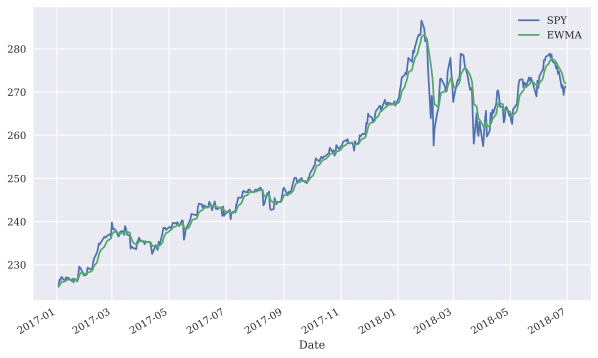

In [158]:
data[data.index > '2017-1-1'].plot(figsize=(10, 6));

### Pure Python

Now consider more general Python function `ewma_py()`. It can be applied
directly on the column or the raw financial times series data in the form of an
ndarray object:

In [159]:
def ewma_py(x, alpha):
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1-alpha) * y[i-1]
    return y

In [160]:
%time data['EWMA_PY'] = ewma_py(data[sym], alpha)  

CPU times: user 41.6 ms, sys: 962 μs, total: 42.6 ms
Wall time: 42.8 ms


In [161]:
%time data['EWMA_PY'] = ewma_py(data[sym].values, alpha)  

CPU times: user 1.94 ms, sys: 0 ns, total: 1.94 ms
Wall time: 1.94 ms


This approach already speeds up the code execution considerably — by a factor
of from about 20 to more than 100.

### Numba

The very structure of this algorithm promises further speedups when applying
Numba. And indeed, when the function ewma_nb() is applied to the ndarray
version of the data, the speedup is again by an order of magnitude:

In [162]:
ewma_nb = numba.jit(ewma_py)

In [163]:
%time data['EWMA_NB'] = ewma_nb(data[sym].values, alpha)  

CPU times: user 252 ms, sys: 13.6 ms, total: 265 ms
Wall time: 266 ms


In [164]:
%timeit data['EWMA_NB'] = ewma_nb(data[sym].values, alpha)  

67.9 μs ± 4.76 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Cython

The Cython version, ewma_cy(), also achieves considerable speed improvements
but it is not as fast as the Numba version in this case

In [165]:
%%cython
import numpy as np
cimport cython
@cython.boundscheck(False)
@cython.wraparound(False)
def ewma_cy(double[:] x, float alpha):
    cdef int i
    cdef double[:] y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y

In [166]:
%time data['EWMA_CY'] = ewma_cy(data[sym].values, alpha)

CPU times: user 480 μs, sys: 12 μs, total: 492 μs
Wall time: 487 μs


In [167]:
%timeit data['EWMA_CY'] = ewma_cy(data[sym].values, alpha)

78.8 μs ± 3.86 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [168]:
data.head()

,SPY,EWMA,EWMA_PY,EWMA_NB,EWMA_CY
Date,,,,,
2010-01-04,113.33,113.330000,113.330000,113.330000,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2010-01-05,113.63,113.405000,113.405000,113.405000,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2010-01-06,113.71,113.481250,113.481250,113.481250,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2010-01-07,114.19,113.658438,113.658438,113.658438,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2010-01-08,114.57,113.886328,113.886328,113.886328,"[113.33, 113.405, 113.48125, 113.6584375, 113...."


In [169]:
data.tail()

,SPY,EWMA,EWMA_PY,EWMA_NB,EWMA_CY
Date,,,,,
2018-06-25,271.00,274.535176,274.535176,274.535176,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2018-06-26,271.60,273.801382,273.801382,273.801382,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2018-06-27,269.35,272.688537,272.688537,272.688537,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2018-06-28,270.89,272.238903,272.238903,272.238903,"[113.33, 113.405, 113.48125, 113.6584375, 113...."
2018-06-29,271.28,271.999177,271.999177,271.999177,"[113.33, 113.405, 113.48125, 113.6584375, 113...."


This final example illustrates again that there are in general multiple options to
implement (nonstandard) algorithms. All options might lead to exactly the same
results, while also showing considerably different performance characteristics.
The execution times in this example range from 0.1 ms to 500 ms — a factor of
5,000 times.

#### BEST VERSUS FIRST-BEST
It is easy in general to translate algorithms to the Python programming language. However, it
is equally easy to implement algorithms in a way that is unnecessarily slow given the menu of
performance options available. For interactive financial analytics, a first-best solution — i.e.,
one that does the trick but which might not be the fastest possible nor the most memory-
efficient one — might be perfectly fine. For financial applications in production, one should
strive to implement the best solution, even though this might involve a bit more research and
some formal benchmarking.

<img src="https://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="https://tpq.io" target="_blank">https://tpq.io</a> | <a href="https://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>